# Assignment 10 — RNN & LSTM Time Series Prediction

**Objective:** Build, train, and compare a Simple RNN and an LSTM model for time-series forecasting using the provided **Household Electric Power Consumption** dataset.

### Dataset used
The exact dataset supplied for this assignment is `data/household_power_consumption.txt`. It contains household electricity measurements recorded at one-minute intervals. The target selected for forecasting is **Global Active Power**.

Because the original file is very high-frequency, the notebook converts the minute-level readings into a **daily average Global Active Power** series. This gives one stable time-series observation per day and makes the RNN/LSTM forecasting task practical while still using the user's original dataset.

**Models:** Simple RNN and LSTM  
**Metrics:** RMSE and MAE  
**Train/Test split:** 80% / 20%, in chronological order


In [4]:
# 1. Imports and configuration
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

os.makedirs("images", exist_ok=True)
os.makedirs("data", exist_ok=True)


TensorFlow version: 2.20.0


## 2. Load the provided dataset

The supplied file uses semicolon (`;`) separators and contains the following fields:
`Date`, `Time`, `Global_active_power`, `Global_reactive_power`, `Voltage`, `Global_intensity`, `Sub_metering_1`, `Sub_metering_2`, and `Sub_metering_3`.

We combine `Date` and `Time` into one datetime column and convert the numeric fields. Missing values represented by `?` are treated as NaN.


In [5]:
# 2. Load the exact user-provided dataset
file_path = "data/household_power_consumption.txt"

df = pd.read_csv(
    file_path,
    sep=";",
    na_values="?",
    low_memory=False
)

df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    dayfirst=True,
    errors="coerce"
)

# Convert measurement columns to numeric
numeric_cols = [
    "Global_active_power", "Global_reactive_power", "Voltage",
    "Global_intensity", "Sub_metering_1", "Sub_metering_2", "Sub_metering_3"
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["Datetime"]).sort_values("Datetime")

print("Raw dataset shape:", df.shape)
display(df.head())
print("\nMissing values in Global_active_power:", df["Global_active_power"].isna().sum())


Raw dataset shape: (848141, 10)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00



Missing values in Global_active_power: 3945


In [6]:
# 3. Create the daily time series used by the neural networks
# Use the exact provided data, but aggregate minute readings to daily mean power.
daily = (
    df.set_index("Datetime")["Global_active_power"]
      .resample("D")
      .mean()
      .interpolate(method="time")
      .dropna()
      .reset_index()
)

daily.rename(columns={"Global_active_power": "Global_Active_Power_Daily_Mean"}, inplace=True)

print("Daily time-series shape:", daily.shape)
display(daily.head())
display(daily.tail())


Daily time-series shape: (590, 2)


,Datetime,Global_Active_Power_Daily_Mean
0,2006-12-16,3.053475
1,2006-12-17,2.354486
2,2006-12-18,1.530435
3,2006-12-19,1.157079
4,2006-12-20,1.545658


,Datetime,Global_Active_Power_Daily_Mean
585,2008-07-23,0.654604
586,2008-07-24,0.759340
587,2008-07-25,0.601065
588,2008-07-26,0.566447
589,2008-07-27,0.634509


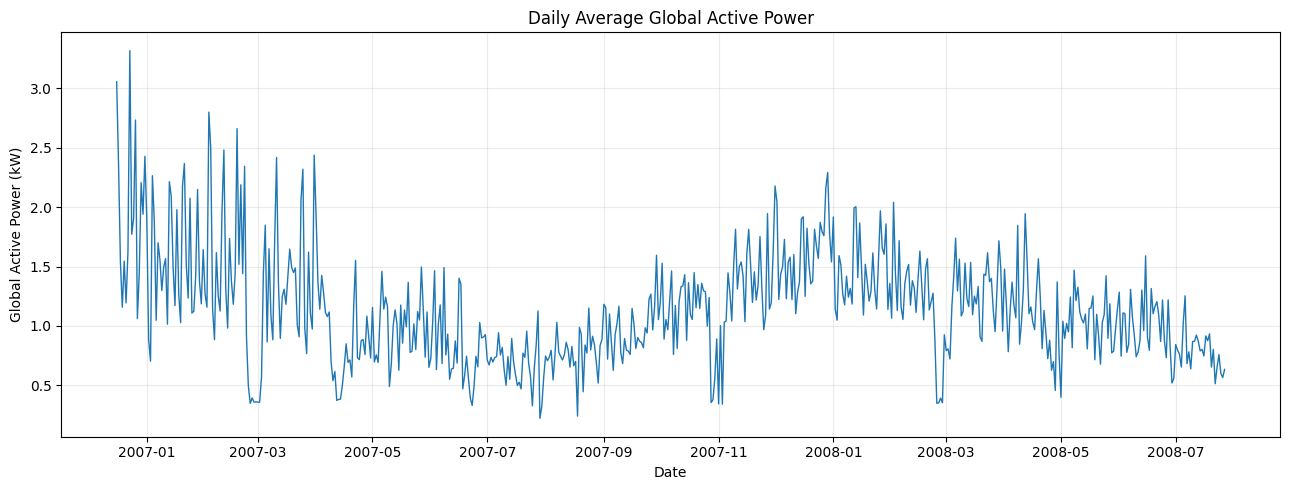

In [7]:
# 4. Exploratory visualization
plt.figure(figsize=(13, 5))
plt.plot(daily["Datetime"], daily["Global_Active_Power_Daily_Mean"], linewidth=1)
plt.title("Daily Average Global Active Power")
plt.xlabel("Date")
plt.ylabel("Global Active Power (kW)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("images/raw_series.png", dpi=150)
plt.show()


## 3. Preprocessing

Steps:
1. Select the daily average Global Active Power series.
2. Split the series chronologically into 80% training and 20% testing data.
3. Fit `MinMaxScaler` **only on the training data** to avoid data leakage.
4. Create sequences using the previous **30 days** to predict the next day.

No random shuffling is used because time order is important in forecasting.


# New Section

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# New Section

# New Section

In [8]:
# 5. Chronological train/test split and scaling
values = daily["Global_Active_Power_Daily_Mean"].values.astype("float32").reshape(-1, 1)

train_size = int(len(values) * 0.80)
train_raw = values[:train_size]

scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(train_raw)
scaled_values = scaler.transform(values)

LOOKBACK = 30

# Include the final 30 training observations before the test period.
train_scaled = scaled_values[:train_size]
test_scaled = scaled_values[train_size - LOOKBACK:]

print(f"Total daily observations: {len(values)}")
print(f"Training observations: {len(train_scaled)}")
print(f"Testing observations: {len(values) - train_size}")


Total daily observations: 590
Training observations: 472
Testing observations: 118


In [9]:
# 6. Convert the time series into supervised-learning sequences
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i + lookback, 0])
        y.append(data[i + lookback, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, LOOKBACK)
X_test, y_test = create_sequences(test_scaled, LOOKBACK)

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)


X_train shape: (442, 30, 1)
X_test shape : (118, 30, 1)


## 4. Simple RNN Model

The Simple RNN uses the previous 30 days of power consumption to predict the next day. Dropout helps reduce overfitting and early stopping stops training when validation performance stops improving.


In [10]:
# 7. Build and train the Simple RNN
rnn_model = Sequential([
    Input(shape=(LOOKBACK, 1)),
    SimpleRNN(64, activation="tanh", return_sequences=True),
    Dropout(0.2),
    SimpleRNN(32, activation="tanh"),
    Dropout(0.2),
    Dense(1)
])

rnn_model.compile(optimizer="adam", loss="mse", metrics=["mae"])
rnn_model.summary()

rnn_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

rnn_history = rnn_model.fit(
    X_train, y_train,
    validation_split=0.10,
    epochs=60,
    batch_size=32,
    callbacks=[rnn_stop],
    verbose=1
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 30, 64)         │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,361 (28.75 KB)

 Trainable params: 7,361 (28.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 0.1741 - mae: 0.3302 - val_loss: 0.0643 - val_mae: 0.2071
Epoch 2/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1013 - mae: 0.2505 - val_loss: 0.0305 - val_mae: 0.1355
Epoch 3/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0710 - mae: 0.2024 - val_loss: 0.0146 - val_mae: 0.0937
Epoch 4/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0521 - mae: 0.1796 - val_loss: 0.0167 - val_mae: 0.1010
Epoch 5/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0471 - mae: 0.1717 - val_loss: 0.0148 - val_mae: 0.0914
Epoch 6/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0386 - mae: 0.1550 - val_loss: 0.0124 - val_mae: 0.0825
Epoch 7/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0333 - mae: 0.1405 - val_loss: 0.0110 - val_mae: 0.0796
Epoch 8/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0293 - mae: 0.1363 - val_loss: 0.0104 - val_mae: 0.0791
Epoch 9/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.029

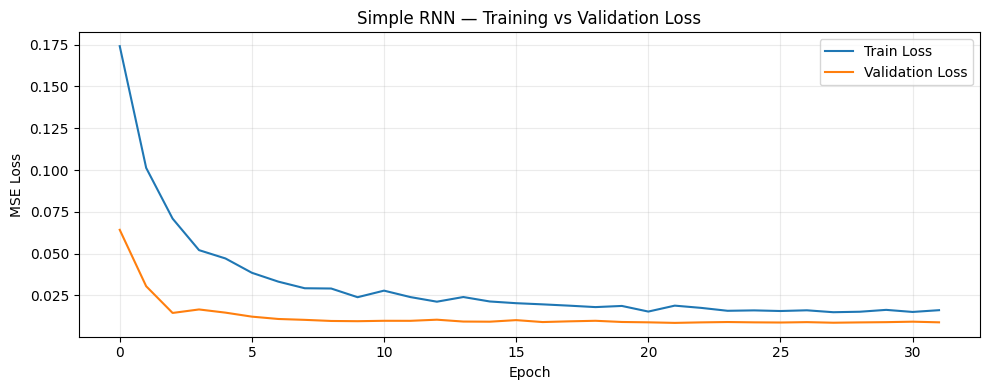

In [11]:
# 8. RNN training curve
plt.figure(figsize=(10, 4))
plt.plot(rnn_history.history["loss"], label="Train Loss")
plt.plot(rnn_history.history["val_loss"], label="Validation Loss")
plt.title("Simple RNN — Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("images/rnn_training_curve.png", dpi=150)
plt.show()


## 5. LSTM Model

The LSTM is another recurrent neural network. It is designed to keep useful information for longer periods and is compared with the Simple RNN using the same input window and evaluation metrics.


In [12]:
# 9. Build and train the LSTM
lstm_model = Sequential([
    Input(shape=(LOOKBACK, 1)),
    LSTM(64, activation="tanh", return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation="tanh"),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(optimizer="adam", loss="mse", metrics=["mae"])
lstm_model.summary()

lstm_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_split=0.10,
    epochs=60,
    batch_size=32,
    callbacks=[lstm_stop],
    verbose=1
)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - loss: 0.0320 - mae: 0.1389 - val_loss: 0.0159 - val_mae: 0.1039
Epoch 2/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0182 - mae: 0.0996 - val_loss: 0.0151 - val_mae: 0.0930
Epoch 3/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0181 - mae: 0.1008 - val_loss: 0.0145 - val_mae: 0.0959
Epoch 4/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0173 - mae: 0.0978 - val_loss: 0.0144 - val_mae: 0.0925
Epoch 5/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0160 - mae: 0.0939 - val_loss: 0.0144 - val_mae: 0.0933
Epoch 6/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0153 - mae: 0.0921 - val_loss: 0.0143 - val_mae: 0.0926
Epoch 7/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0163 - mae: 0.0955 - val_loss: 0.0144 - val_mae: 0.0918
Epoch 8/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0162 - mae: 0.0956 - val_loss: 0.0144 - val_mae: 0.0938
Epoch 9/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.015

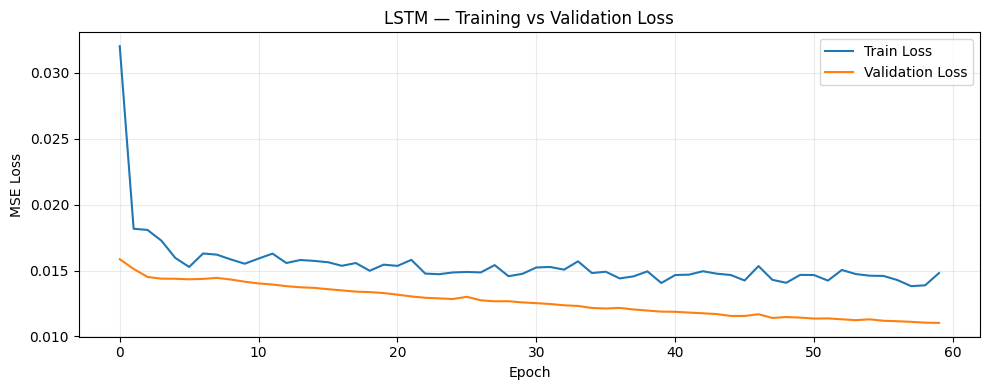

In [13]:
# 10. LSTM training curve
plt.figure(figsize=(10, 4))
plt.plot(lstm_history.history["loss"], label="Train Loss")
plt.plot(lstm_history.history["val_loss"], label="Validation Loss")
plt.title("LSTM — Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("images/lstm_training_curve.png", dpi=150)
plt.show()


## 6. Predictions and Comparison

The predictions are converted back to the original kW scale before plotting and evaluating the models.


In [14]:
# 11. Generate predictions
rnn_pred_scaled = rnn_model.predict(X_test, verbose=0)
lstm_pred_scaled = lstm_model.predict(X_test, verbose=0)

rnn_pred = scaler.inverse_transform(rnn_pred_scaled).ravel()
lstm_pred = scaler.inverse_transform(lstm_pred_scaled).ravel()
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()

test_dates = daily["Datetime"].iloc[train_size:].reset_index(drop=True)

comparison = pd.DataFrame({
    "Date": test_dates,
    "Actual": y_test_actual,
    "Simple_RNN": rnn_pred,
    "LSTM": lstm_pred
})

display(comparison.head(10))


,Date,Actual,Simple_RNN,LSTM
0,2008-04-01,1.478508,1.091889,1.246804
1,2008-04-02,1.174772,1.299082,1.258452
2,2008-04-03,0.783858,1.207127,1.238980
3,2008-04-04,1.133276,1.197089,1.159909
4,2008-04-05,1.368585,1.355453,1.130334
5,2008-04-06,1.177999,1.194853,1.154194
6,2008-04-07,1.068637,1.052945,1.164512
7,2008-04-08,1.845497,1.228349,1.153504
8,2008-04-09,0.846425,1.359647,1.250594
9,2008-04-10,1.026212,0.992959,1.212797


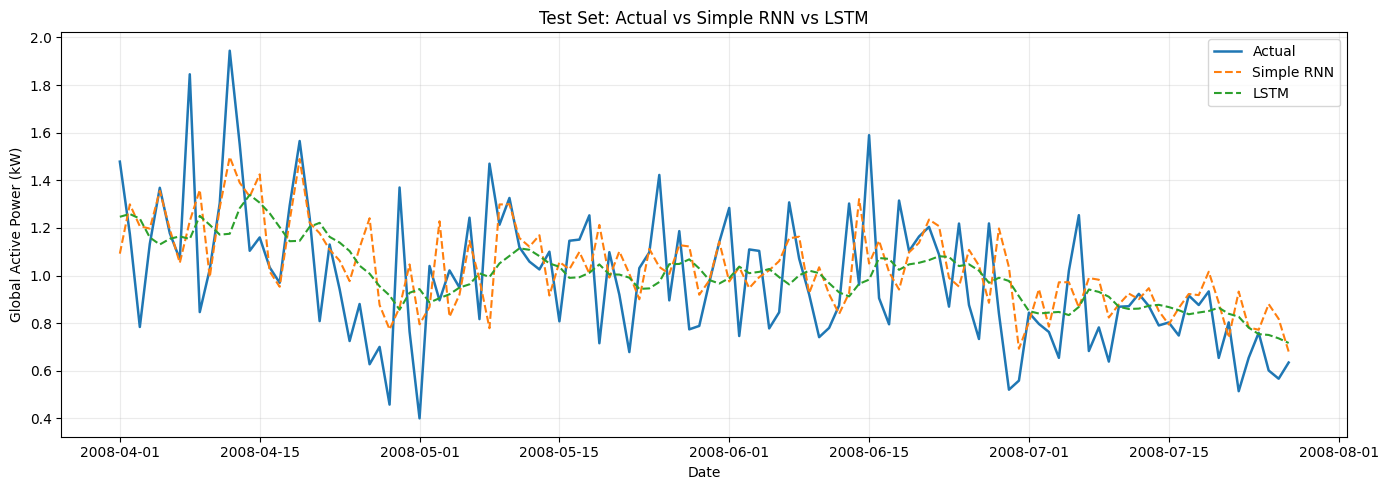

In [15]:
# 12. Actual vs RNN vs LSTM
plt.figure(figsize=(14, 5))
plt.plot(test_dates, y_test_actual, label="Actual", linewidth=1.8)
plt.plot(test_dates, rnn_pred, label="Simple RNN", linestyle="--")
plt.plot(test_dates, lstm_pred, label="LSTM", linestyle="--")
plt.title("Test Set: Actual vs Simple RNN vs LSTM")
plt.xlabel("Date")
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("images/prediction_comparison.png", dpi=150)
plt.show()


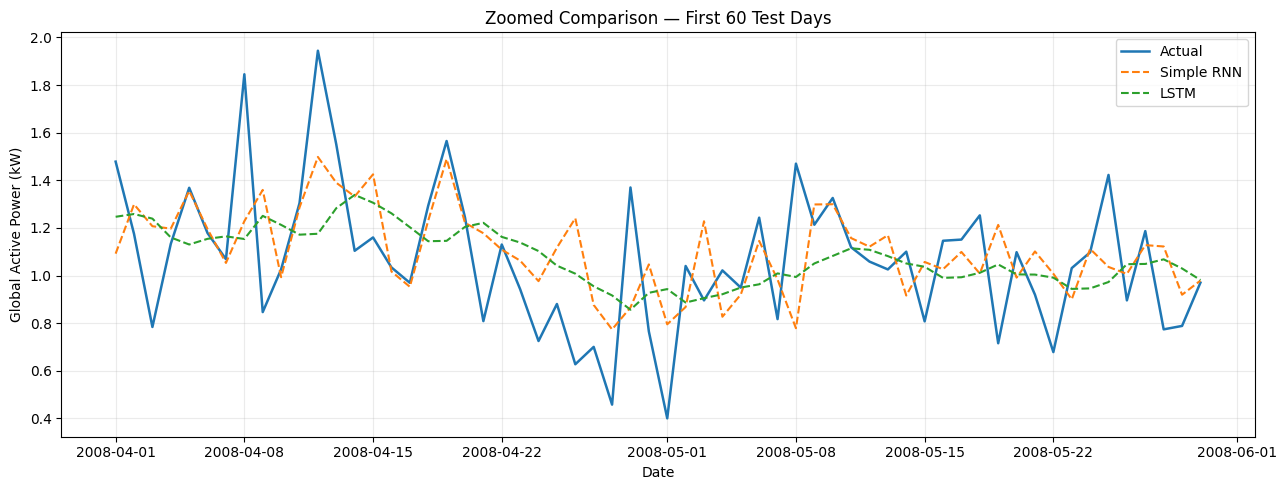

In [16]:
# 13. Zoomed comparison for the first 60 test days
n_zoom = min(60, len(y_test_actual))
plt.figure(figsize=(13, 5))
plt.plot(test_dates.iloc[:n_zoom], y_test_actual[:n_zoom], label="Actual", linewidth=1.8)
plt.plot(test_dates.iloc[:n_zoom], rnn_pred[:n_zoom], label="Simple RNN", linestyle="--")
plt.plot(test_dates.iloc[:n_zoom], lstm_pred[:n_zoom], label="LSTM", linestyle="--")
plt.title(f"Zoomed Comparison — First {n_zoom} Test Days")
plt.xlabel("Date")
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("images/prediction_comparison_zoom.png", dpi=150)
plt.show()


## 7. Evaluation Metrics

We use **RMSE** and **MAE**. Both are calculated on the original kW scale. Lower values mean the model's predictions are closer to the actual values.


In [17]:
# 14. Calculate RMSE and MAE
def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return {"Model": name, "RMSE": round(rmse, 4), "MAE": round(mae, 4)}

results_df = pd.DataFrame([
    evaluate(y_test_actual, rnn_pred, "Simple RNN"),
    evaluate(y_test_actual, lstm_pred, "LSTM")
])

results_df.to_csv("data/evaluation_metrics.csv", index=False)
display(results_df)

best_rmse_model = results_df.loc[results_df["RMSE"].idxmin(), "Model"]
best_mae_model = results_df.loc[results_df["MAE"].idxmin(), "Model"]

print("Best model by RMSE:", best_rmse_model)
print("Best model by MAE :", best_mae_model)


,Model,RMSE,MAE
0,Simple RNN,0.2463,0.1879
1,LSTM,0.2484,0.1960


Best model by RMSE: Simple RNN
Best model by MAE : Simple RNN


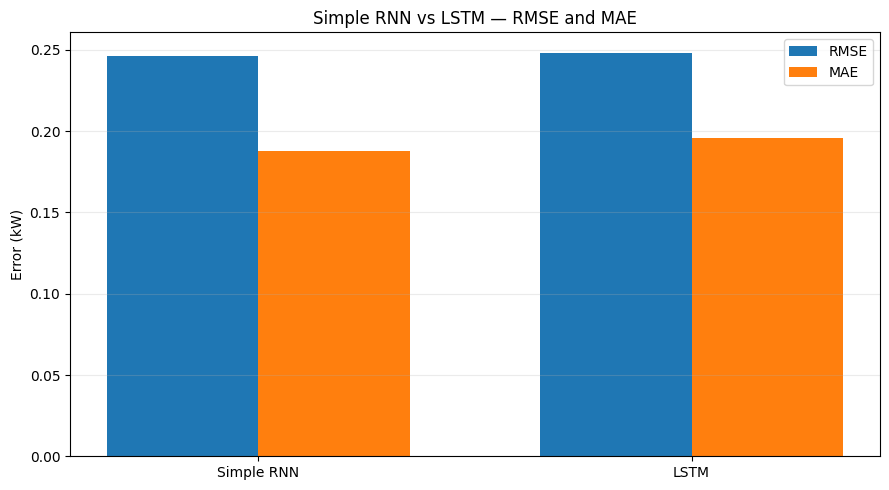

In [18]:
# 15. Metrics comparison
x = np.arange(len(results_df))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, results_df["RMSE"], width, label="RMSE")
ax.bar(x + width/2, results_df["MAE"], width, label="MAE")
ax.set_xticks(x)
ax.set_xticklabels(results_df["Model"])
ax.set_ylabel("Error (kW)")
ax.set_title("Simple RNN vs LSTM — RMSE and MAE")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig("images/metrics_comparison.png", dpi=150)
plt.show()


## 8. Conclusion

This assignment uses the **provided Household Electric Power Consumption dataset**, not a synthetic dataset. The minute-level `Global_active_power` readings were aggregated to daily mean power so that the RNN and LSTM models can learn a clear daily time-series pattern.

The final model comparison is produced automatically in the `results_df` table. The model with the lower RMSE and MAE is the better model for this test period.

### Key points
- The dataset contains real household electricity measurements.
- The target variable is daily average **Global Active Power**.
- The data is split chronologically to respect time order.
- MinMax scaling is fitted only on the training data.
- A 30-day lookback window is used to predict the next day.
- Simple RNN and LSTM are compared using RMSE and MAE.

**Important:** Run all cells before submission so the notebook contains the actual training curves, predictions, and evaluation results generated from this dataset.
